# Проект: Прогнозирование стоимости недвижимости

## Этап 1. Исследование данных (EDA)

### 1.1 Знакомство с данными

In [1]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('real_estate_data.csv')
df.shape

(403487, 17)

В датасете 403 487 строк и 17 столбцов.

In [3]:
df.head()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


In [4]:
df.tail()

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


In [26]:
df.sample(1, random_state=1)

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency,rooms_total,city
253215,253216,Konut,Daire,10/23/18,11/8/18,1,16,0,10-20 arası,6,2+1,NaN,Adana/Seyhan/2000 Evler,NaN,Kombi (Doğalgaz),183000.0,TRY,3.0,Adana


Датасет содержит объявления о продаже и аренде недвижимости с турецкого сервиса Zingat. Это площадка-посредник между покупателями/арендаторами и продавцами/арендодателями недвижимости.

Описание признаков:
- id — номер объявления;
- type — тип недвижимости (в датасете только одно значение — Konut, т.е. жильё);
- sub_type — подтип жилья (Daire — квартира, Villa — вилла и т.д.);
- start_date / end_date — даты публикации и снятия объявления;
- listing_type — тип объявления: 1 — продажа, 2 — аренда, 3 — прочее;
- tom — сколько дней объявление находилось на рынке (time on market);
- building_age — возраст здания;
- total_floor_count — этажность дома;
- floor_no — этаж, на котором расположена квартира;
- room_count — количество комнат (например, 2+1 — 2 комнаты + гостиная);
- size — площадь в м²;
- address — адрес в формате город/район/квартал;
- furnished — меблировка;
- heating_type — тип отопления;
- price — цена (целевая переменная);
- price_currency` — валюта цены.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403487 entries, 0 to 403486
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 403487 non-null  int64  
 1   type               403487 non-null  object 
 2   sub_type           403487 non-null  object 
 3   start_date         403487 non-null  object 
 4   end_date           266298 non-null  object 
 5   listing_type       403487 non-null  int64  
 6   tom                403487 non-null  int64  
 7   building_age       376097 non-null  object 
 8   total_floor_count  375466 non-null  object 
 9   floor_no           368191 non-null  object 
 10  room_count         403487 non-null  object 
 11  size               257481 non-null  float64
 12  address            403487 non-null  object 
 13  furnished          0 non-null       float64
 14  heating_type       375517 non-null  object 
 15  price              402772 non-null  float64
 16  pr

Всего 3 числовых столбца (float64), 3 столбца int64 и 11 столбцов типа object. По df.info() сразу видно, что часть столбцов (end_date, building_age, size, furnished и др.) содержат пропуски.

### 1.2 Описательная статистика

In [7]:
df.describe()

,id,listing_type,tom,size,furnished,price
count,403487.00000,403487.000000,403487.000000,257481.000000,0.0,4.027720e+05
mean,201744.00000,1.294235,57.022739,279.349094,NaN,3.546417e+05
std,116476.80837,0.467733,44.358933,9429.195331,NaN,4.809503e+06
min,1.00000,1.000000,0.000000,1.000000,NaN,-2.500000e+02
25%,100872.50000,1.000000,29.000000,85.000000,NaN,2.500000e+03
50%,201744.00000,1.000000,40.000000,110.000000,NaN,1.990000e+05
75%,302615.50000,2.000000,90.000000,140.000000,NaN,3.420000e+05
max,403487.00000,3.000000,180.000000,948235.000000,NaN,2.000000e+09


По числовым столбцам:
- listing_type — медиана 1, то есть среди объявлений преобладает продажа (1), аренда (2) встречается реже;
- tom — объявление в среднем находится на рынке 57 дней, максимум ограничен 180 днями;
- size — здесь явно есть выбросы: медиана 110 м², а максимум почти 950 000 м², так быть не может;
- furnished — count = 0, то есть столбец полностью пустой, толку от него не будет;
- price — та же история, что и с площадью: медиана ≈ 199 000, а максимум — 2 млрд, огромные выбросы.

In [8]:
df.describe(include='object')

,type,sub_type,start_date,end_date,building_age,total_floor_count,floor_no,room_count,address,heating_type,price_currency
count,403487,403487,403487,266298,376097,375466,368191,403487,403487,375517,402772
unique,1,12,181,181,14,12,44,37,7842,16,4
top,Konut,Daire,10/11/18,12/19/18,0,4,2,3+1,Balıkesir/Edremit/Akçay,Kombi (Doğalgaz),TRY
freq,403487,354549,4064,3048,140174,83082,60914,157363,5611,204150,400677


По категориальным столбцам:
- type — всего 1 уникальное значение (Konut), для модели это бесполезный признак;
- sub_type — 12 категорий, чаще всего встречается Daire (квартира);
- room_count — больше всего вариантов 3+1;
- address — очень много уникальных адресов (это, по сути, город/район/квартал одной строкой), напрямую в модель такой признак не пойдёт, нужно будет разбивать.

In [10]:
print('Асимметрия цены:', df['price'].skew())

Асимметрия цены: 308.50702657456833


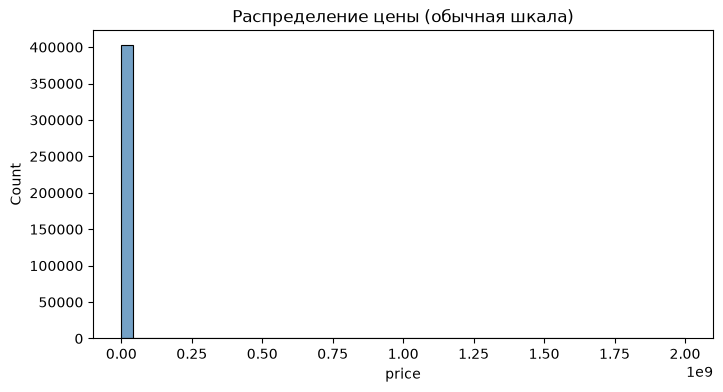

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df.loc[df['price'] > 0, 'price'], bins=50, color='steelblue')
plt.title('Распределение цены (обычная шкала)')
plt.show()

Асимметрия цены огромная, и на гистограмме в обычной шкале это отлично видно: почти все столбики прижаты к нулю, а редкие огромные выбросы растягивают ось так, что основное распределение не разглядеть. Перед моделированием цену, скорее всего, нужно будет логарифмировать — в логарифмической шкале распределение выглядит гораздо адекватнее.

### 1.3 Визуальный анализ

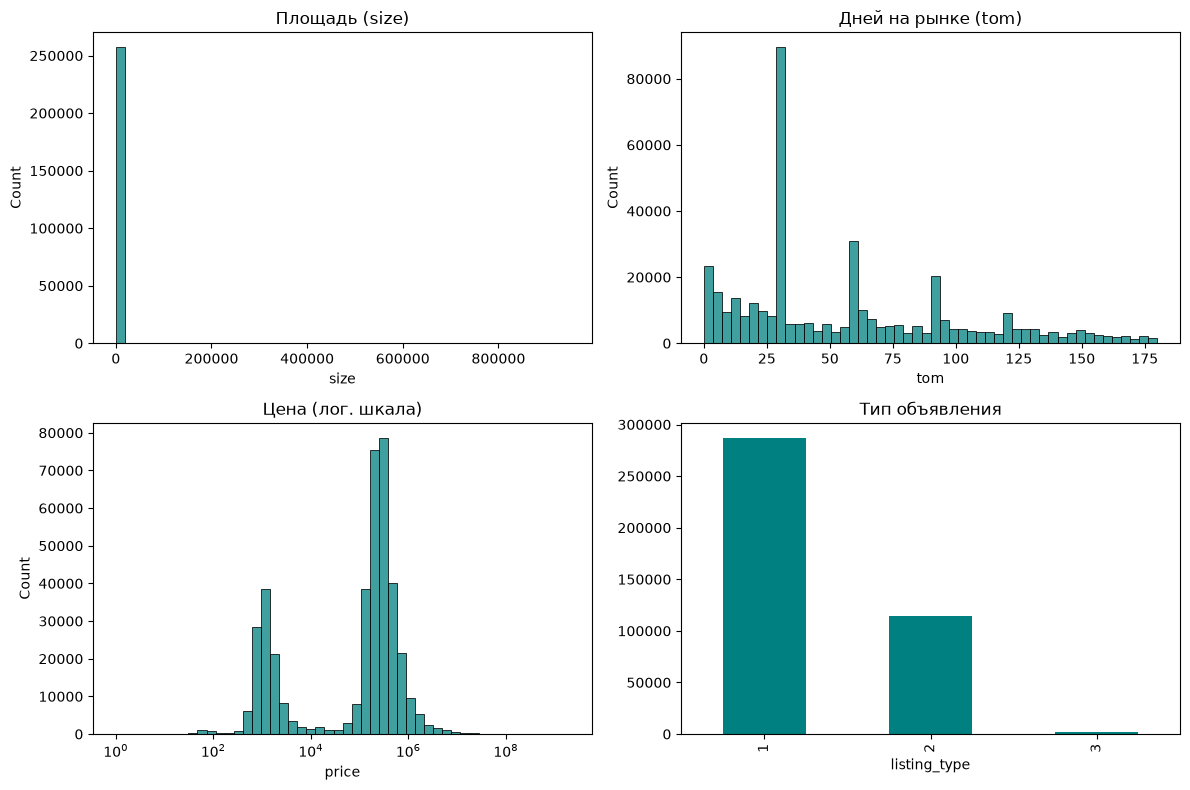

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['size'].dropna(), bins=50, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Площадь (size)')

sns.histplot(df['tom'], bins=50, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Дней на рынке (tom)')

sns.histplot(df.loc[df['price'] > 0, 'price'], bins=50, log_scale=True, ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Цена (лог. шкала)')

df['listing_type'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Тип объявления')

plt.tight_layout()
plt.show()

- size — гистограмма сжата в одну точку слева из-за редких аномально больших значений;
- tom — резкие пики на 30, 60, 90, 120, 180 днях, похоже, что площадка сама снимает объявления по этим срокам;
- price в логарифмической шкале — видно два «горба»: слева это аренда (цены поменьше), справа — продажа;
- listing_type — продажа (1) встречается гораздо чаще аренды (2), тип 3 почти не встречается.

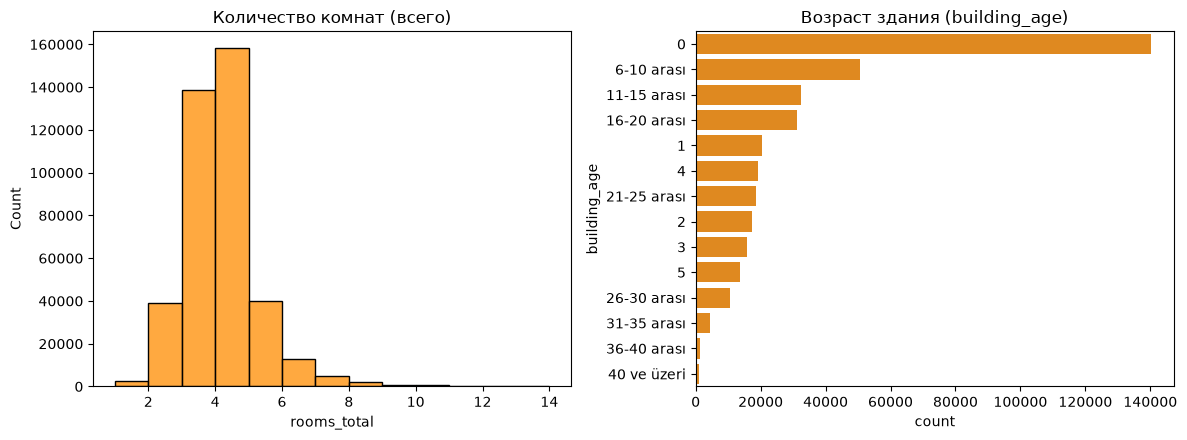

In [13]:
import re

def parse_rooms(value):
    if pd.isna(value):
        return np.nan
    nums = re.findall(r'\d+', str(value))
    if len(nums) == 2:
        return int(nums[0]) + int(nums[1])
    return np.nan

df['rooms_total'] = df['room_count'].apply(parse_rooms)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df['rooms_total'].dropna(), bins=range(1, 15), ax=axes[0], color='darkorange')
axes[0].set_title('Количество комнат (всего)')

age_order = df['building_age'].value_counts().index
sns.countplot(data=df, y='building_age', order=age_order, ax=axes[1], color='darkorange')
axes[1].set_title('Возраст здания (building_age)')

plt.tight_layout()
plt.show()

Чаще всего встречаются квартиры с 3-4 комнатами всего (то есть 2+1 и 3+1). По возрасту здания больше всего новостроек ('0' — только что построенные), дальше идут дома возрастом 6-10 лет.

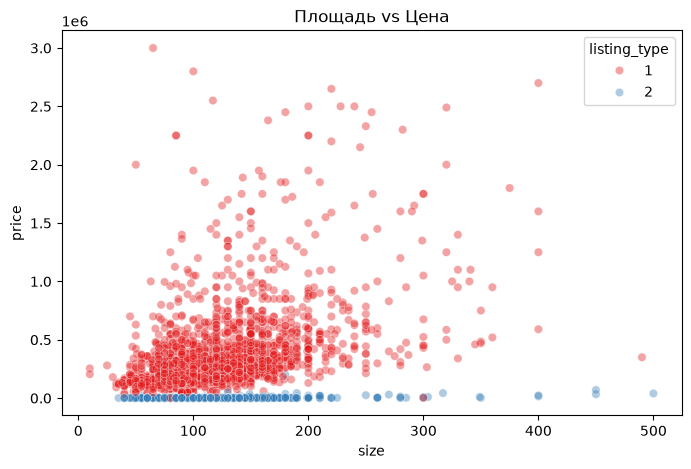

In [14]:
sample = df[df['size'].between(10, 500) & df['price'].between(1000, 3_000_000)].sample(3000, random_state=1)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x='size', y='price', hue='listing_type', alpha=0.4, palette='Set1')
plt.title('Площадь vs Цена')
plt.show()

Чем больше площадь, тем выше цена — зависимость видна, хотя разброс большой. Также хорошо видно, что точки аренды (listing_type=2) лежат заметно ниже точек продажи (listing_type=1) — это две разные ценовые категории.

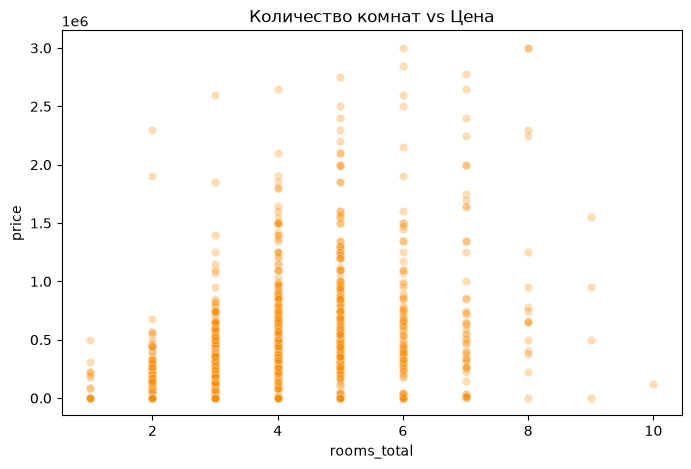

In [15]:
sample2 = df[df['price'].between(1000, 3_000_000) & df['rooms_total'].between(1, 10)].sample(3000, random_state=1)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample2, x='rooms_total', y='price', alpha=0.3, color='darkorange')
plt.title('Количество комнат vs Цена')
plt.show()

Цена тоже растёт вместе с количеством комнат, но тут разброс ещё больше, чем у площади — скорее всего потому что количество комнат само по себе грубее площади (например, 3+1 может быть и 70 м², и 130 м²).

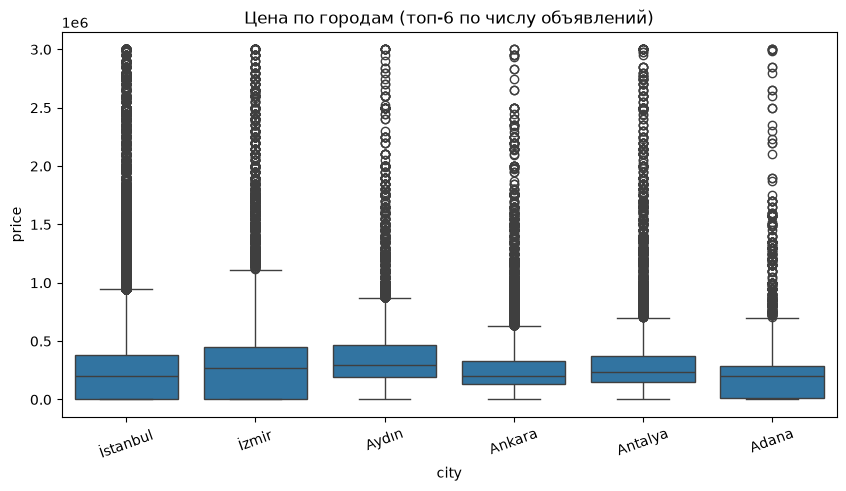

In [16]:
df['city'] = df['address'].str.split('/').str[0]
top_cities = df['city'].value_counts().head(6).index

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df[df['city'].isin(top_cities) & df['price'].between(1000, 3_000_000)],
    x='city', y='price'
)
plt.xticks(rotation=20)
plt.title('Цена по городам (топ-6 по числу объявлений)')
plt.show()

Из адреса выделила город. В топ-6 городов по числу объявлений median-цена сильно различается: например, в Айдыне и Измире цены выше, чем в Стамбуле и Анкаре, хотя объявлений в Стамбуле больше всего. Значит, город/район — важный признак.

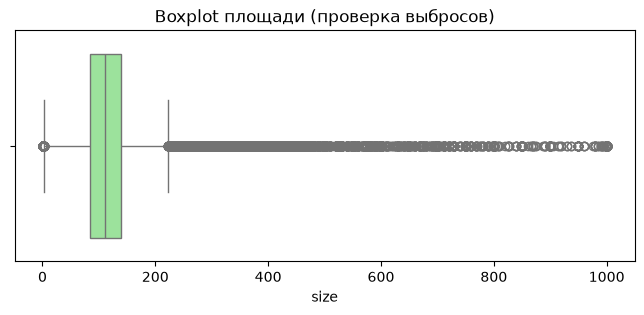

In [17]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df[df['size'].between(1, 1000)]['size'], color='lightgreen')
plt.title('Boxplot площади (проверка выбросов)')
plt.show()

Даже если сразу ограничить площадь до 1000 м², boxplot всё равно показывает огромное количество точек-выбросов справа. Это ещё раз подтверждает, что на этапе предобработки площадь нужно будет чистить от аномалий.

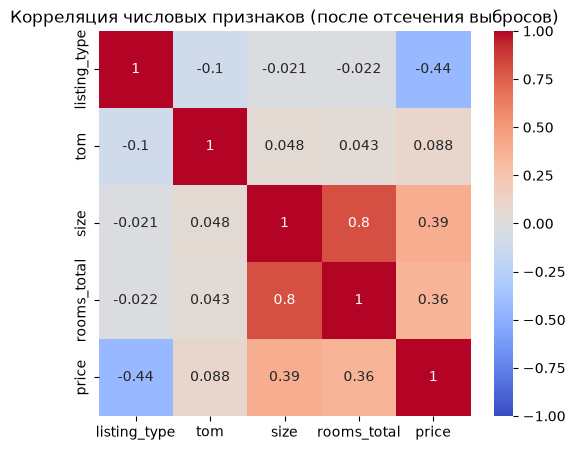

In [18]:
num_cols = ['listing_type', 'tom', 'size', 'rooms_total', 'price']
filtered = df[df['size'].between(10, 500) & df['price'].between(1000, 3_000_000)]

plt.figure(figsize=(6, 5))
sns.heatmap(filtered[num_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляция числовых признаков (после отсечения выбросов)')
plt.show()

Сначала я считала корреляцию на «сырых» данных, но из-за огромных выбросов в price и size она получалась почти нулевой и бессмысленной. После отсечения явных аномалий (площадь 10–500 м², цена 1000–3 000 000) картина стала понятнее:
- listing_type и price — заметная отрицательная связь (-0.44): у аренды (2) цена меньше, чем у продажи (1);
- size и price — положительная связь (+0.39): больше площадь — выше цена;
- rooms_total и price — тоже положительная связь (+0.36), похожая на площадь, что логично — это связанные признаки;
- tom почти не связан с ценой.

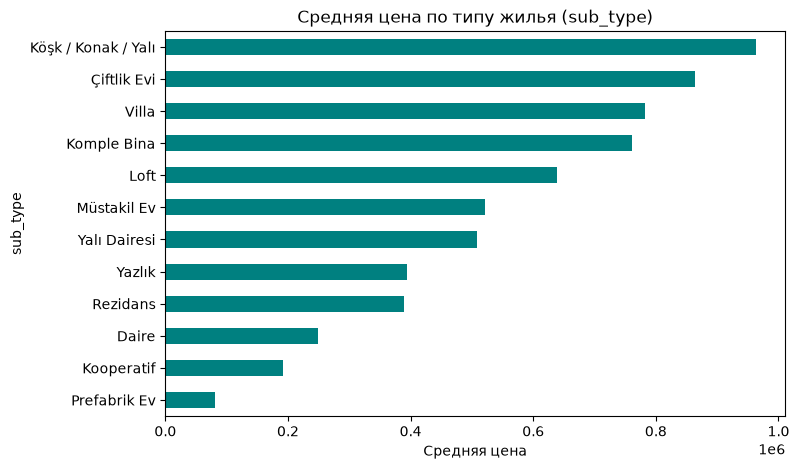

In [19]:
mean_price = filtered.groupby('sub_type')['price'].mean().sort_values()

plt.figure(figsize=(8, 5))
mean_price.plot(kind='barh', color='teal')
plt.title('Средняя цена по типу жилья (sub_type)')
plt.xlabel('Средняя цена')
plt.show()

Самые дешёвые в среднем — сборные дома (Prefabrik Ev), самые дорогие — особняки/усадьбы (Köşk/Konak/Yalı) и виллы. Обычная квартира (Daire, самая частая категория) по цене где-то в середине списка.

### 1.4 Анализ пропусков и аномалий

In [20]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'пропусков': missing, 'процент, %': missing_pct}).sort_values('процент, %', ascending=False)

,пропусков,"процент, %"
furnished,403487,100.00
size,146006,36.19
end_date,137189,34.00
floor_no,35296,8.75
total_floor_count,28021,6.94
heating_type,27970,6.93
building_age,27390,6.79
rooms_total,2898,0.72
price_currency,715,0.18
price,715,0.18


Больше всего пропусков в furnished — 100%, столбец совсем без данных, на следующем этапе его логично удалить. Дальше по количеству пропусков: end_date (34%), size (36%), floor_no (9%), total_floor_count и heating_type (7%), building_age (7%). У price/price_currency пропусков мало (715 строк).

In [27]:
df.duplicated().sum()

np.int64(0)

Полных дубликатов строк нет.

In [28]:
df['id'].duplicated().sum()

np.int64(0)

По id тоже дубликатов нет

In [23]:
print('Цены <= 0:', (df['price'] <= 0).sum())
print('Площадь <= 0:', (df['size'] <= 0).sum())
df['price_currency'].value_counts(dropna=False)

Цены <= 0: 45
Площадь <= 0: 0


price_currency
TRY    400677
EUR       922
NaN       715
GBP       621
USD       552
Name: count, dtype: int64

Есть 44 объявления с ценой 0 и 1 с ценой отрицательной — это явные ошибки ввода, такие строки нужно будет убрать. Отрицательных/нулевых значений площади нет. Валюта в основном TRY, но встречаются USD, EUR, GBP (и 715 пропусков) — цены в разных валютах напрямую сравнивать нельзя, нужно будет привести к одной.

In [24]:
df['building_age'].value_counts()

building_age
0              140174
6-10 arası      50495
11-15 arası     32309
16-20 arası     31333
1               20355
4               19032
21-25 arası     18438
2               17466
3               15651
5               13589
26-30 arası     10581
31-35 arası      4268
36-40 arası      1347
40 ve üzeri      1059
Name: count, dtype: int64

Значения building_age выглядят адекватно: 0 — новостройка, остальные — диапазоны лет ('6-10 arası' и т.п.), проверила на нереалистичные значения (отрицательный возраст, дом старше 100 лет и т.п.) — таких не нашлось.

In [25]:
print('Не удалось распознать формат room_count:', df['rooms_total'].isna().sum())
df.loc[df['rooms_total'].isna(), 'room_count'].value_counts()

Не удалось распознать формат room_count: 2898


room_count
+    2898
Name: count, dtype: int64

Нашла ещё одну аномалию: у 2898 объявлений room_count равен просто + без единой цифры — явно битые данные, из текста никак не понять, сколько там комнат. На этапе предобработки такие строки, скорее всего, придётся удалить или заполнить самой частой категорией.

### 1.5 Промежуточные выводы

По итогам первого этапа можно сформулировать несколько гипотез, которые проверю на следующих этапах:

1. **Тип объявления (продажа/аренда) сильнее всего влияет на цену** — на боксплоте и в корреляции разница между продажей и арендой хорошо видна.
2. **Площадь (size) положительно влияет на цену** — подтверждается диаграммой рассеяния и корреляцией (+0.39 после очистки от выбросов).
3. **Город/район важен для цены** — медианная цена по топ-городам заметно различается.
4. **Тип жилья (sub_type) тоже влияет на цену** — виллы и особняки в среднем в несколько раз дороже квартир и сборных домов.
5. **Без очистки от выбросов и пропусков модель работать не будет** — в `price` и `size` огромные выбросы (вплоть до 2 млрд и почти 1 млн м²), а `furnished` придётся удалить полностью из-за 100% пропусков.